<a href="https://colab.research.google.com/github/Sakshid9/Crypto-prediction-using-deep-learning-and-sentiment-analysis/blob/main/Copy_of_RBL_Cryptopredictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
#Importing libraries
import pandas as pd
import numpy as np
import xgboost as xgp
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [ ]:
import yfinance as yf
import pandas as pd

# Download Bitcoin and Ethereum data
btc_data = yf.download('BTC-USD', start='2020-01-01', end='2024-12-01')
eth_data = yf.download('ETH-USD', start='2020-01-01', end='2024-12-01')

# Display the first few rows of each dataset
print("Bitcoin Data:")
print(btc_data.head())

print("Ethereum Data:")
print(eth_data.head())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Bitcoin Data:
Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095
Ethereum Data:
Price            Close        High         Low        Open       Volume
Ticker         ETH-USD     ETH-USD     ETH-USD     ETH-USD      ETH-USD
Date                                                                   
2020-01-01  130.802002  132.835358  129.198288  129.630661   7935230330
2020-01-02  127.410179  130.820038  126.954910  130.820038   8032709256
202

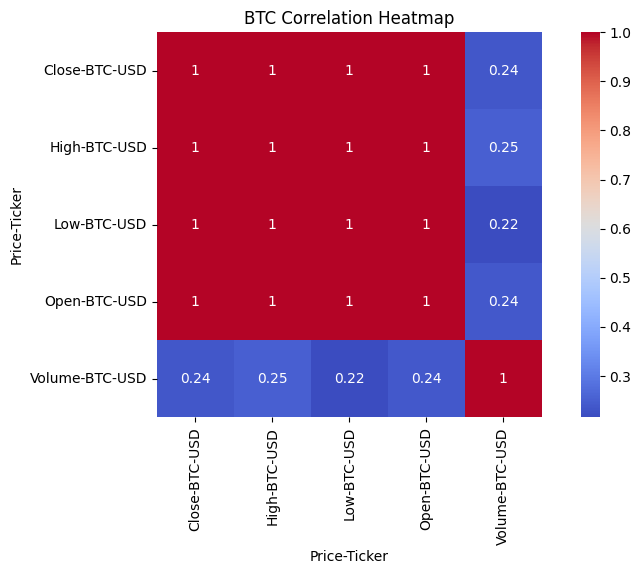

In [ ]:
# Correlation Heatmap for BTC
plt.figure(figsize=(10, 5))
correlations_btc = btc_data.corr()
sns.heatmap(data=correlations_btc, square=True, cmap="coolwarm", annot=True)
plt.title("BTC Correlation Heatmap")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

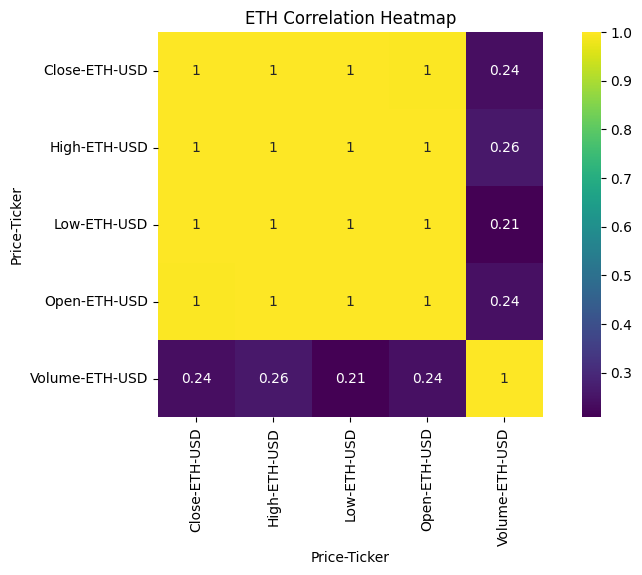

In [ ]:
# Correlation Heatmap for ETH
plt.figure(figsize=(10, 5))
correlations_eth = eth_data.corr()
sns.heatmap(data=correlations_eth, square=True, cmap="viridis", annot=True)
plt.title("ETH Correlation Heatmap")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Handle missing values
for column in btc_data.columns:
    if btc_data[column].dtype != 'object':
        btc_data[column].fillna(btc_data[column].mean(), inplace=True)

for column in eth_data.columns:
    if eth_data[column].dtype != 'object':
        eth_data[column].fillna(eth_data[column].mean(), inplace=True)

In [ ]:
import pandas as pd

# Ensure btc_data and eth_data are DataFrames
if not isinstance(btc_data, pd.DataFrame) or not isinstance(eth_data, pd.DataFrame):
    raise TypeError("btc_data and eth_data must be pandas DataFrames.")

# Print dataset structure for debugging
print("BTC Data Columns:", btc_data.columns)
print("ETH Data Columns:", eth_data.columns)

BTC Data Columns: MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])
ETH Data Columns: MultiIndex([( 'Close', 'ETH-USD'),
            (  'High', 'ETH-USD'),
            (   'Low', 'ETH-USD'),
            (  'Open', 'ETH-USD'),
            ('Volume', 'ETH-USD')],
           names=['Price', 'Ticker'])


In [ ]:
# Flatten MultiIndex columns
btc_data.columns = ['_'.join(col) for col in btc_data.columns]
eth_data.columns = ['_'.join(col) for col in eth_data.columns]

# Print new column names
print("Flattened BTC Data Columns:", btc_data.columns)
print("Flattened ETH Data Columns:", eth_data.columns)

Flattened BTC Data Columns: Index(['Close_BTC-USD', 'High_BTC-USD', 'Low_BTC-USD', 'Open_BTC-USD',
       'Volume_BTC-USD'],
      dtype='object')
Flattened ETH Data Columns: Index(['Close_ETH-USD', 'High_ETH-USD', 'Low_ETH-USD', 'Open_ETH-USD',
       'Volume_ETH-USD'],
      dtype='object')


In [ ]:
import pandas as pd

# Convert relevant columns to numeric values
for col in ['Close_BTC-USD', 'Open_BTC-USD', 'Volume_BTC-USD']:
    btc_data[col] = pd.to_numeric(btc_data[col], errors='coerce')

for col in ['Close_ETH-USD', 'Open_ETH-USD', 'Volume_ETH-USD']:
    eth_data[col] = pd.to_numeric(eth_data[col], errors='coerce')

# Drop any NaN values introduced
btc_data.dropna(subset=['Close_BTC-USD', 'Open_BTC-USD', 'Volume_BTC-USD'], inplace=True)
eth_data.dropna(subset=['Close_ETH-USD', 'Open_ETH-USD', 'Volume_ETH-USD'], inplace=True)

In [ ]:
# Moving Average (MA50)
def moving_average(data, column, window=50):
    return data[column].rolling(window=window).mean()

# Relative Strength Index (RSI)
def relative_strength_index(data, column, period=14):
    delta = data[column].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

# Moving Average Convergence Divergence (MACD)
def macd(data, column, short_period=12, long_period=26, signal_period=9):
    short_ema = data[column].ewm(span=short_period, adjust=False).mean()
    long_ema = data[column].ewm(span=long_period, adjust=False).mean()
    macd_line = short_ema - long_ema
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    return macd_line, signal_line

In [ ]:
# Apply indicators to Bitcoin dataset
btc_data['BTC_MA_50'] = moving_average(btc_data, 'Close_BTC-USD')
btc_data['BTC_RSI'] = relative_strength_index(btc_data, 'Close_BTC-USD')
btc_data['BTC_MACD'], btc_data['BTC_Signal_Line'] = macd(btc_data, 'Close_BTC-USD')

# Apply indicators to Ethereum dataset
eth_data['ETH_MA_50'] = moving_average(eth_data, 'Close_ETH-USD')
eth_data['ETH_RSI'] = relative_strength_index(eth_data, 'Close_ETH-USD')
eth_data['ETH_MACD'], eth_data['ETH_Signal_Line'] = macd(eth_data, 'Close_ETH-USD')

# Drop NaN values introduced by indicator calculations
btc_data.dropna(inplace=True)
eth_data.dropna(inplace=True)

# Display preview
print("Bitcoin Data with Technical Indicators:")
print(btc_data.head())

print("\nEthereum Data with Technical Indicators:")
print(eth_data.head())

Bitcoin Data with Technical Indicators:
            Close_BTC-USD  High_BTC-USD  Low_BTC-USD  Open_BTC-USD  \
Date                                                                 
2020-02-19    9633.386719  10191.675781  9611.223633  10143.798828   
2020-02-20    9608.475586   9643.216797  9507.900391   9629.325195   
2020-02-21    9686.441406   9723.014648  9589.743164   9611.782227   
2020-02-22    9663.181641   9698.231445  9600.728516   9687.707031   
2020-02-23    9924.515625   9937.404297  9657.791016   9663.318359   

            Volume_BTC-USD    BTC_MA_50    BTC_RSI    BTC_MACD  \
Date                                                             
2020-02-19     46992019710  8932.137070  50.320471  290.951893   
2020-02-20     44925260237  8980.303096  47.993384  247.808511   
2020-02-21     40930547513  9034.322520  48.196001  217.402183   
2020-02-22     35838025154  9080.688467  46.622060  189.246563   
2020-02-23     41185185761  9130.965645  46.796126  185.877817   

      

In [ ]:
# Bitcoin Sentiment Analysis
# import the libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from textblob import TextBlob

In [ ]:
# import the data
df_path = "/content/Bitcoin_tweets.csv"
df = pd.read_csv(df_path)

df.head(10)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False
1,CryptoND,NaN,😎 BITCOINLIVE is a Dutch platform aimed at inf...,2019-10-17 20:12:10,6769,1532,25483,False,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""...","['Thursday', 'Btc', 'wallet', 'security']",Twitter for Android,False
2,Tdlmatias,"London, England","IM Academy : The best #forex, #SelfEducation, ...",2014-11-10 10:50:37,128,332,924,False,2021-02-10 23:54:48,"Guys evening, I have read this article about B...",NaN,Twitter Web App,False
3,Crypto is the future,NaN,I will post a lot of buying signals for BTC tr...,2019-09-28 16:48:12,625,129,14,False,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...,"['Bitcoin', 'FX', 'BTC', 'crypto']",dlvr.it,False
4,Alex Kirchmaier 🇦🇹🇸🇪 #FactsSuperspreader,Europa,Co-founder @RENJERJerky | Forbes 30Under30 | I...,2016-02-03 13:15:55,1249,1472,10482,False,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...,['BTC'],Twitter Web App,False
5,ZerrBenz™ ⚔ ✪ 20732,"Bkk, Thailand",I'm a cat slave 🐱 Interested in Blockchain · T...,2010-01-12 07:00:04,742,716,2444,False,2021-02-10 23:53:30,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,"['Crypto', 'Binance', 'Cashback']",Twitter Web App,False
6,Bitcoin-Bot,"Florida, USA",Bot to generate Bitcoin picture as combination...,2019-12-23 16:49:16,131,84,5728,False,2021-02-10 23:53:17,&lt;'fire' &amp; 'man'&gt;\n#Bitcoin #Crypto #...,"['Bitcoin', 'Crypto', 'BTC']",BTC_p_bot,False
7,Cryptocurrencies / EUR,NaN,Stay updated on the main cryptocurrencies of t...,2018-08-03 21:30:08,4052,1,9,False,2021-02-10 23:52:42,🔄 Prices update in $EUR (1 hour):\n\n$BTC - ...,NaN,Cryptocurrencies prices to EUR,False
8,Mikcoin,NaN,"Technical Analyst | Trader\n\nNo certainty, on...",2020-11-26 23:45:46,104,41,238,False,2021-02-10 23:52:25,#BTC #Bitcoin #Ethereum #ETH #Crypto #cryptotr...,"['BTC', 'Bitcoin', 'Ethereum', 'ETH', 'Crypto'...",Twitter Web App,False
9,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534,7605,4838,False,2021-02-10 23:52:08,.@Tesla’s #bitcoin investment is revolutionary...,"['bitcoin', 'crypto']",Twitter Web App,False


In [ ]:
# remove nan value row in hastags column
df. dropna(subset = ["hashtags"], inplace=True)
df.head(5)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False
1,CryptoND,NaN,😎 BITCOINLIVE is a Dutch platform aimed at inf...,2019-10-17 20:12:10,6769,1532,25483,False,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""...","['Thursday', 'Btc', 'wallet', 'security']",Twitter for Android,False
3,Crypto is the future,NaN,I will post a lot of buying signals for BTC tr...,2019-09-28 16:48:12,625,129,14,False,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...,"['Bitcoin', 'FX', 'BTC', 'crypto']",dlvr.it,False
4,Alex Kirchmaier 🇦🇹🇸🇪 #FactsSuperspreader,Europa,Co-founder @RENJERJerky | Forbes 30Under30 | I...,2016-02-03 13:15:55,1249,1472,10482,False,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...,['BTC'],Twitter Web App,False
5,ZerrBenz™ ⚔ ✪ 20732,"Bkk, Thailand",I'm a cat slave 🐱 Interested in Blockchain · T...,2010-01-12 07:00:04,742,716,2444,False,2021-02-10 23:53:30,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,"['Crypto', 'Binance', 'Cashback']",Twitter Web App,False


In [ ]:
# total value size
print("Tweet Size: ", len(df))

Tweet Size:  38416


In [ ]:
# get only texts
df = df[['text']]
df.columns = ['tweets']

In [ ]:
# create a function to clean the tweets
def cleanTwt(twt):
    twt = re.sub("#bitcoin", 'bitcoin', twt) # removes the '#' from bitcoin
    twt = re.sub("#Bitcoin", 'Bitcoin', twt) # removes the '#' from Bitcoin
    twt = re.sub('#[A-Za-z0-9]+', '', twt) # removes any string with a '#'
    twt = re.sub('\\n', '', twt) # removes the '\n' string
    twt = re.sub('https:\/\/\S+', '', twt) # removes any hyperlinks
    return twt

In [ ]:
df['cleaned_tweets'] = df['tweets'].apply(cleanTwt)
df

,tweets,cleaned_tweets
0,Blue Ridge Bank shares halted by NYSE after #b...,Blue Ridge Bank shares halted by NYSE after bi...
1,"😎 Today, that's this #Thursday, we will do a ""...","😎 Today, that's this , we will do a ""🎬 Take 2""..."
3,$BTC A big chance in a billion! Price: \487264...,$BTC A big chance in a billion! Price: \487264...
4,This network is secured by 9 508 nodes as of t...,This network is secured by 9 508 nodes as of t...
5,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,💹 Trade on 📌 Enjoy 10% of the Trading fee📌 ...
...,...,...
48577,$BTC pop or drop?\n\n#volatility in 3...2...1....,$BTC pop or drop? in 3...2...1... Bitcoin or
48578,Bill Gates advised against investing in #Bitco...,Bill Gates advised against investing in Bitcoi...
48579,#Bitcoin price in US Dollar #BTC $usd #BTCUSD ...,Bitcoin price in US Dollar $usd $XBT BTC Pr...
48580,Market Id : BTC-AUD\nLast Price :74260.91\n24 ...,Market Id : BTC-AUDLast Price :74260.9124 Hour...


In [ ]:
# create a function to get subjectivity
def getSubjectivity(twt):
    return TextBlob(twt).sentiment.subjectivity

# create a function to get the polarity
def getPolarity(twt):
    return TextBlob(twt).sentiment.polarity

# create two new columns called "Subjectivity" & "Polarity"
df['subjectivity'] = df['cleaned_tweets'].apply(getSubjectivity)
df['polarity'] = df['cleaned_tweets'].apply(getPolarity)

In [ ]:
df.head(5)

,tweets,cleaned_tweets,subjectivity,polarity
0,Blue Ridge Bank shares halted by NYSE after #b...,Blue Ridge Bank shares halted by NYSE after bi...,0.1,0.0
1,"😎 Today, that's this #Thursday, we will do a ""...","😎 Today, that's this , we will do a ""🎬 Take 2""...",0.0,0.0
3,$BTC A big chance in a billion! Price: \487264...,$BTC A big chance in a billion! Price: \487264...,0.1,0.0
4,This network is secured by 9 508 nodes as of t...,This network is secured by 9 508 nodes as of t...,0.1,0.0
5,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,💹 Trade on 📌 Enjoy 10% of the Trading fee📌 ...,0.5,0.4


In [ ]:
# create a function get the sentiment text
def getSentiment(score):
    if score < 0:
        return "negative"
    elif score == 0:
        return "neutral"
    else:
        return "positive"

# create a column to store the text sentiment
df['sentiment'] = df['polarity'].apply(getSentiment)

# show the data
df.head()

,tweets,cleaned_tweets,subjectivity,polarity,sentiment
0,Blue Ridge Bank shares halted by NYSE after #b...,Blue Ridge Bank shares halted by NYSE after bi...,0.1,0.0,neutral
1,"😎 Today, that's this #Thursday, we will do a ""...","😎 Today, that's this , we will do a ""🎬 Take 2""...",0.0,0.0,neutral
3,$BTC A big chance in a billion! Price: \487264...,$BTC A big chance in a billion! Price: \487264...,0.1,0.0,neutral
4,This network is secured by 9 508 nodes as of t...,This network is secured by 9 508 nodes as of t...,0.1,0.0,neutral
5,💹 Trade #Crypto on #Binance \n\n📌 Enjoy #Cashb...,💹 Trade on 📌 Enjoy 10% of the Trading fee📌 ...,0.5,0.4,positive


<ipython-input-28-93ea00c74105>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='subjectivity', y='sentiment', inner='box', palette='Dark2')


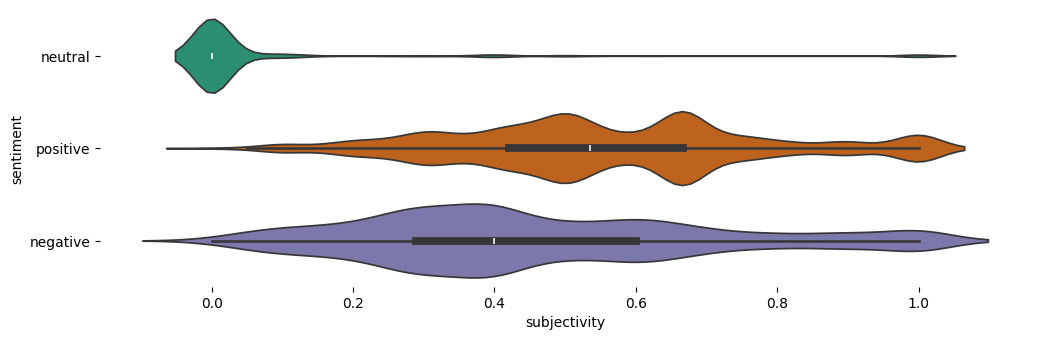

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['sentiment'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='subjectivity', y='sentiment', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

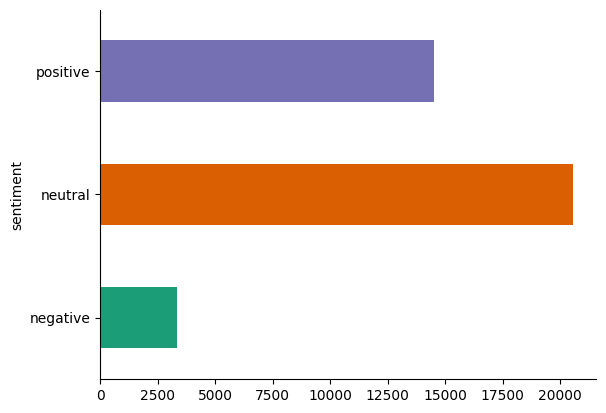

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

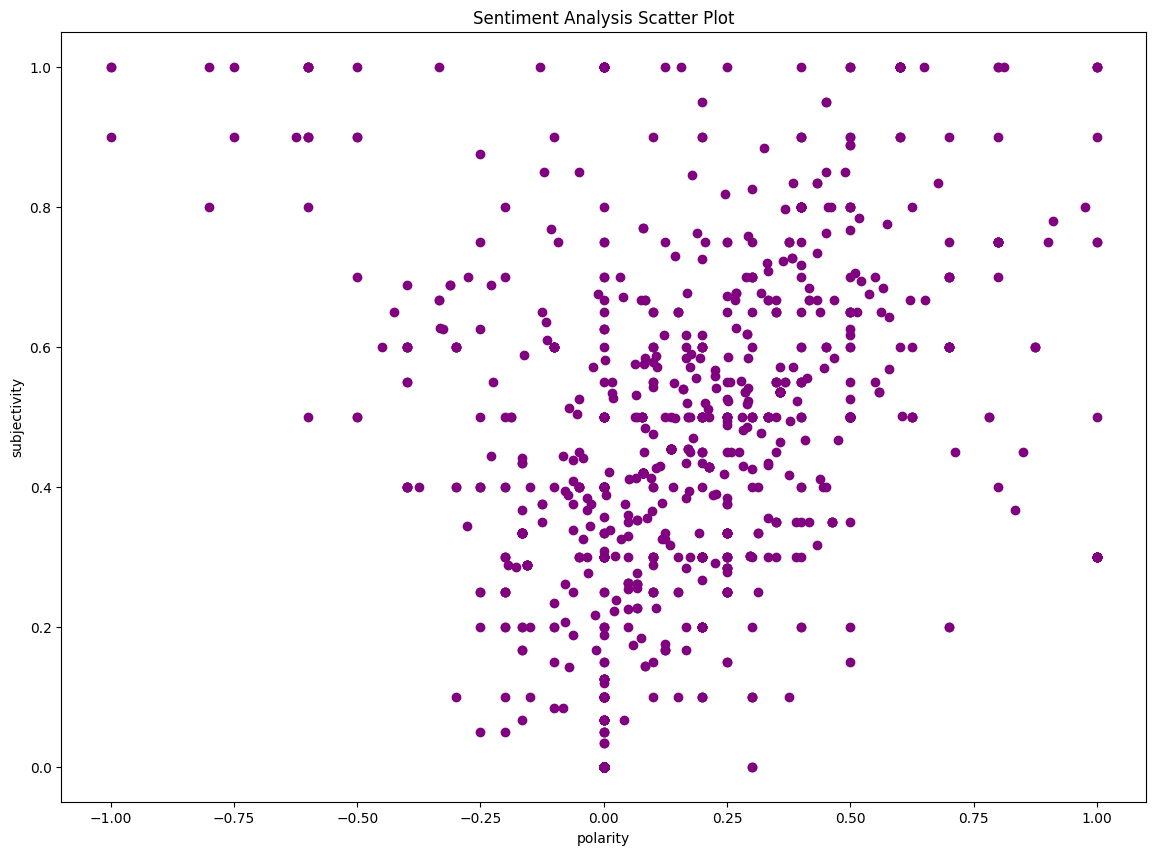

In [ ]:
# create a scatter plot to show the subjectivity and the polarity
plt.figure(figsize=(14,10))

for i in range(0, 2000):
    plt.scatter(df["polarity"].iloc[[i]].values[0], df["subjectivity"].iloc[[i]].values[0], color="Purple")

plt.title("Sentiment Analysis Scatter Plot")
plt.xlabel('polarity')
plt.ylabel('subjectivity')
plt.show()

Etherium Sentiment Analysis

In [ ]:
import pandas as pd
import numpy as np
import altair as alt
from gensim.utils import simple_preprocess# this will do a lot of the preprocessing required for us
from sklearn.preprocessing import StandardScaler as SC
from dateutil import parser
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
df = pd.read_csv("/content/SEthB.csv")
df

,id,author,score,subreddit,text,label,created_time
0,gc7oxa8,joenorwood77,1.0,CryptoCurrency,"With sidechains like Ethereum , Elastos is not...",neither,2020-11-14 01:39:38
1,gq9wglp,d3tra,1.0,CryptoCurrency,"However , since you asked I think you 're bett...",favor,2021-03-09 00:32:07
2,gnqvbdy,kushkloudzz,1.0,CryptoCurrency,The are several services that will allow you t...,neither,2021-02-17 08:24:02
3,gi5byja,Johnmcal,1.0,ethereum,I think part of it is with with how much ETH a...,favor,2021-01-05 04:27:09
4,gq3l747,SwagtimusPrime,1.0,CryptoCurrency,"Companies just need to realize that , especial...",favor,2021-03-07 14:31:30
...,...,...,...,...,...,...,...
769,gn5qezg,crunchywetleaves,1.0,CryptoCurrency,\r\n\r\n There 's plenty of coins that do what...,against,2021-02-13 08:03:50
770,gukwj80,lastog9,2.0,CryptoCurrency,"Of course , what I meant is ETH has the potent...",favor,2021-04-15 07:01:38
771,gea4hch,funkymonk44,5.0,CryptoCurrency,"As someone who holds 75 - 80 % ETH , what make...",neither,2020-12-01 18:04:22
772,gtwzb2f,GroundbreakingLack78,1.0,CryptoCurrency,I believe that Ethereum will slowly but surely...,favor,2021-04-09 10:40:28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            774 non-null    object 
 1   author        774 non-null    object 
 2   score         774 non-null    float64
 3   subreddit     774 non-null    object 
 4   text          774 non-null    object 
 5   label         774 non-null    object 
 6   created_time  774 non-null    object 
dtypes: float64(1), object(6)
memory usage: 42.5+ KB


In [ ]:
# Convert date column to datetime format
df.rename(columns={"created_time": "date"}, inplace=True)  # Adjust if needed
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
df.head(5)

,id,author,score,subreddit,text,label,date
0,gc7oxa8,joenorwood77,1.0,CryptoCurrency,"With sidechains like Ethereum , Elastos is not...",neither,2020-11-14 01:39:38
1,gq9wglp,d3tra,1.0,CryptoCurrency,"However , since you asked I think you 're bett...",favor,2021-03-09 00:32:07
2,gnqvbdy,kushkloudzz,1.0,CryptoCurrency,The are several services that will allow you t...,neither,2021-02-17 08:24:02
3,gi5byja,Johnmcal,1.0,ethereum,I think part of it is with with how much ETH a...,favor,2021-01-05 04:27:09
4,gq3l747,SwagtimusPrime,1.0,CryptoCurrency,"Companies just need to realize that , especial...",favor,2021-03-07 14:31:30


In [ ]:
if "text" not in df:
    print("Error: No 'text' column found! Please check column names.")
else:
    print("Text column detected. Proceeding with sentiment analysis.")

Text column detected. Proceeding with sentiment analysis.


In [ ]:
# Rename the columns of the DataFrame to include 'eth-' prefix
df.rename(columns={
    'score': 'eth-score',
    'subreddit': 'eth-subreddit',
    'text': 'eth-tweets',
    'label': 'eth-label',
}, inplace=True)
df.head(5)

,id,author,eth-score,eth-subreddit,eth-tweets,eth-label,date
0,gc7oxa8,joenorwood77,1.0,CryptoCurrency,"With sidechains like Ethereum , Elastos is not...",neither,2020-11-14 01:39:38
1,gq9wglp,d3tra,1.0,CryptoCurrency,"However , since you asked I think you 're bett...",favor,2021-03-09 00:32:07
2,gnqvbdy,kushkloudzz,1.0,CryptoCurrency,The are several services that will allow you t...,neither,2021-02-17 08:24:02
3,gi5byja,Johnmcal,1.0,ethereum,I think part of it is with with how much ETH a...,favor,2021-01-05 04:27:09
4,gq3l747,SwagtimusPrime,1.0,CryptoCurrency,"Companies just need to realize that , especial...",favor,2021-03-07 14:31:30


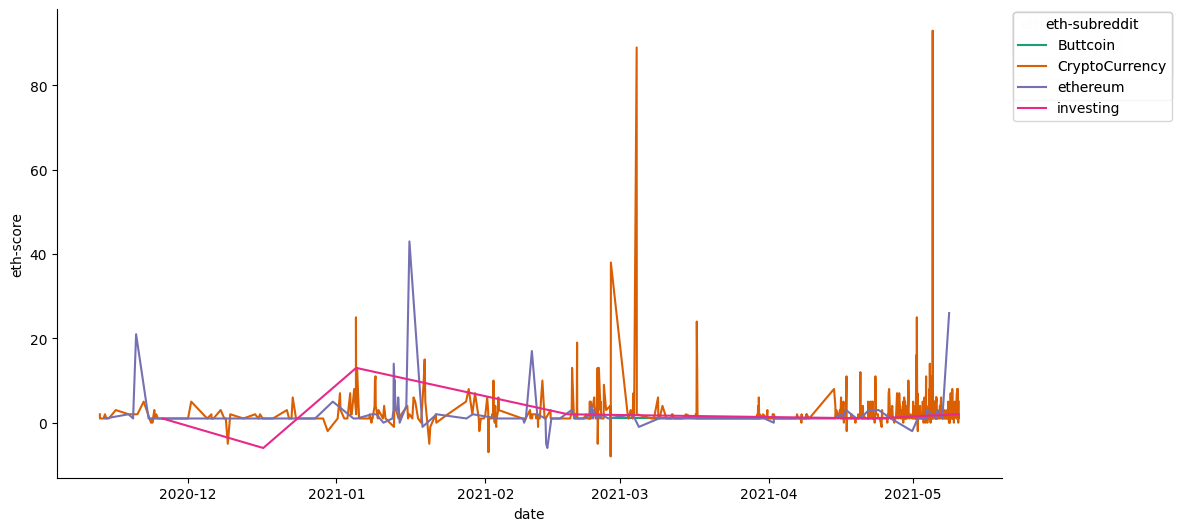

In [ ]:
# @title date vs eth-score

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['eth-score']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('eth-subreddit')):
  _plot_series(series, series_name, i)
  fig.legend(title='eth-subreddit', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('eth-score')

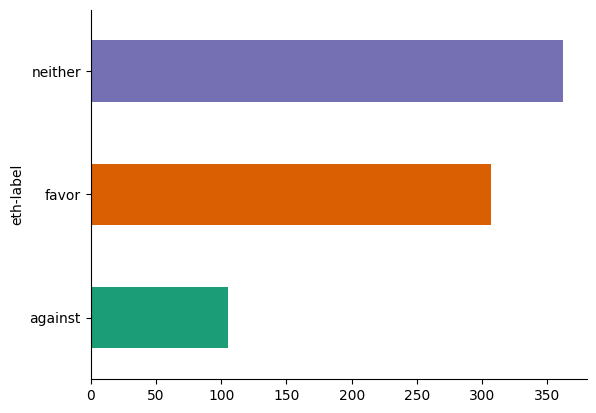

In [ ]:
# @title eth-label
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('eth-label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
!pip install vaderSentiment

<ipython-input-51-f3ec380d905a>:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = df['sentiment_score'].resample('M').mean()


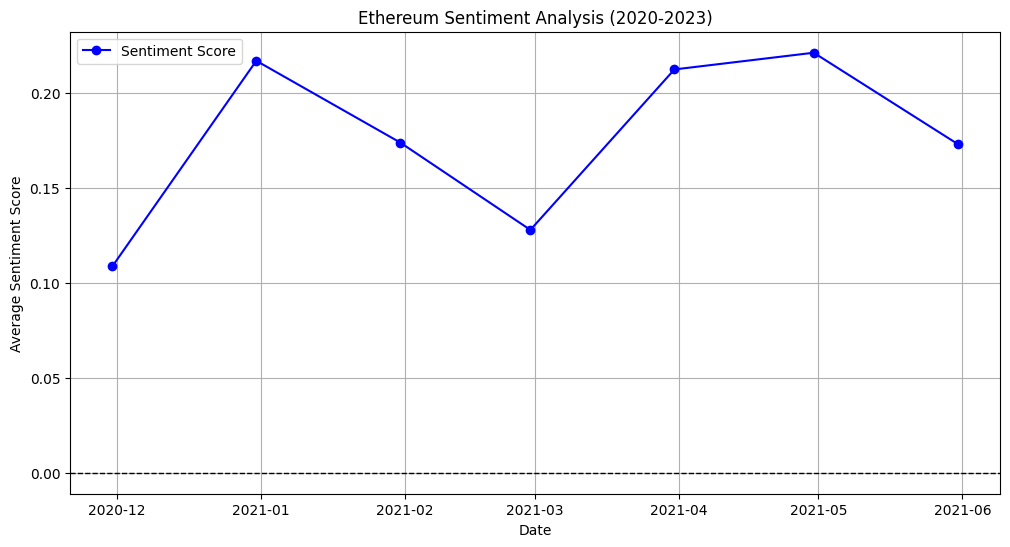

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Perform sentiment analysis on the 'eth-tweets' column
df['sentiment_score'] = df['eth-tweets'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Convert 'eth-date' to datetime if it's not already
df['date'] = pd.to_datetime(df['date'])

# Set 'eth-date' as the index for time-based resampling
df.set_index('date', inplace=True)

# Resample by month to calculate average sentiment score
monthly_sentiment = df['sentiment_score'].resample('M').mean()

# Plot Sentiment Trends
plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment, marker='o', linestyle='-', color='blue', label='Sentiment Score')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Neutral sentiment line
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.title('Ethereum Sentiment Analysis (2020-2023)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the DataFrame df as 'eth-sent.csv'
df.to_csv('eth-sent.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import matplotlib.pyplot as plt

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Select features for BTC and ETH
btc_features = btc_data[['Open_BTC-USD', 'High_BTC-USD', 'Low_BTC-USD', 'Volume_BTC-USD',
                         'BTC_MA_50', 'BTC_RSI', 'BTC_MACD', 'BTC_Signal_Line']]
eth_features = eth_data[['Open_ETH-USD', 'High_ETH-USD', 'Low_ETH-USD', 'Volume_ETH-USD',
                         'ETH_MA_50', 'ETH_RSI', 'ETH_MACD', 'ETH_Signal_Line']]

# Scale the feature data
btc_scaled = scaler.fit_transform(btc_features)
eth_scaled = scaler.fit_transform(eth_features)

# Scale the target variable (Close price for prediction)
btc_target = scaler.fit_transform(btc_data[['Close_BTC-USD']])
eth_target = scaler.fit_transform(eth_data[['Close_ETH-USD']])

In [ ]:
# Function to create dataset for LSTM model
def create_dataset(data, target, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(target[i + time_step, 0])
    return np.array(X), np.array(y)

# Create datasets
time_step = 60  # Use past 60 days to predict next day's close price
X_btc, y_btc = create_dataset(btc_scaled, btc_target, time_step)
X_eth, y_eth = create_dataset(eth_scaled, eth_target, time_step)

In [ ]:
X_btc_train, X_btc_test, y_btc_train, y_btc_test = train_test_split(X_btc, y_btc, test_size=0.2, shuffle=False)
X_eth_train, X_eth_test, y_eth_train, y_eth_test = train_test_split(X_eth, y_eth, test_size=0.2, shuffle=False)

# Function to build LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dense(units=1))  # Output: Predict closing price
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create LSTM models for BTC & ETH
btc_model = build_lstm_model((X_btc_train.shape[1], X_btc_train.shape[2]))
eth_model = build_lstm_model((X_eth_train.shape[1], X_eth_train.shape[2]))

# Train BTC model
btc_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Train ETH model
eth_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Make predictions
btc_predictions = btc_model.predict(X_btc_test)
eth_predictions = eth_model.predict(X_eth_test)

# Inverse transform predictions to original price scale
btc_predictions = scaler.inverse_transform(btc_predictions)
btc_actual = scaler.inverse_transform(y_btc_test.reshape(-1, 1))

eth_predictions = scaler.inverse_transform(eth_predictions)
eth_actual = scaler.inverse_transform(y_eth_test.reshape(-1, 1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0141
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 9.9285e-04
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 7.1384e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 6.8344e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 5.4926e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 5.6298e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 4.9020e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4.6499e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 4.6768e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 4.3016e-04
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0264
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0021
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0018
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0019
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2

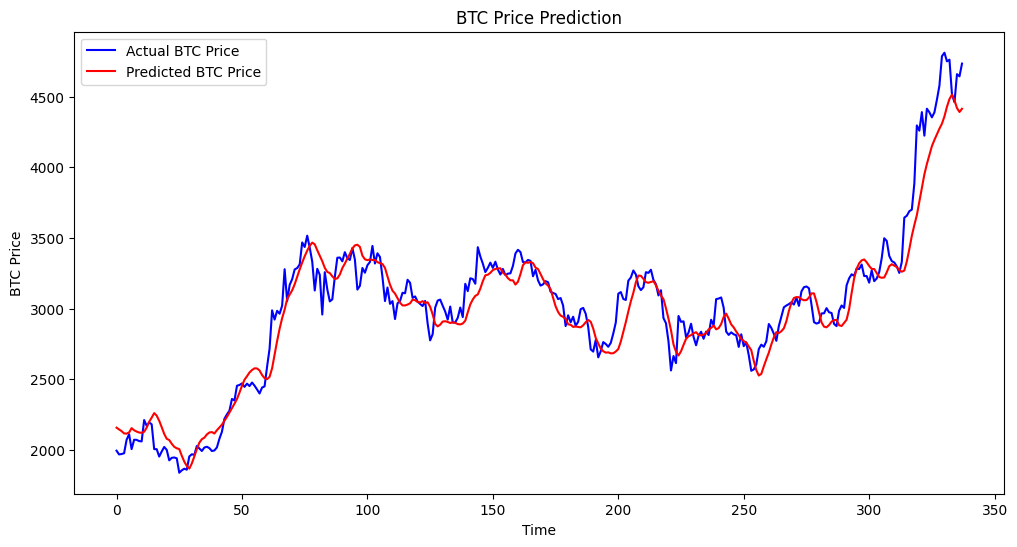

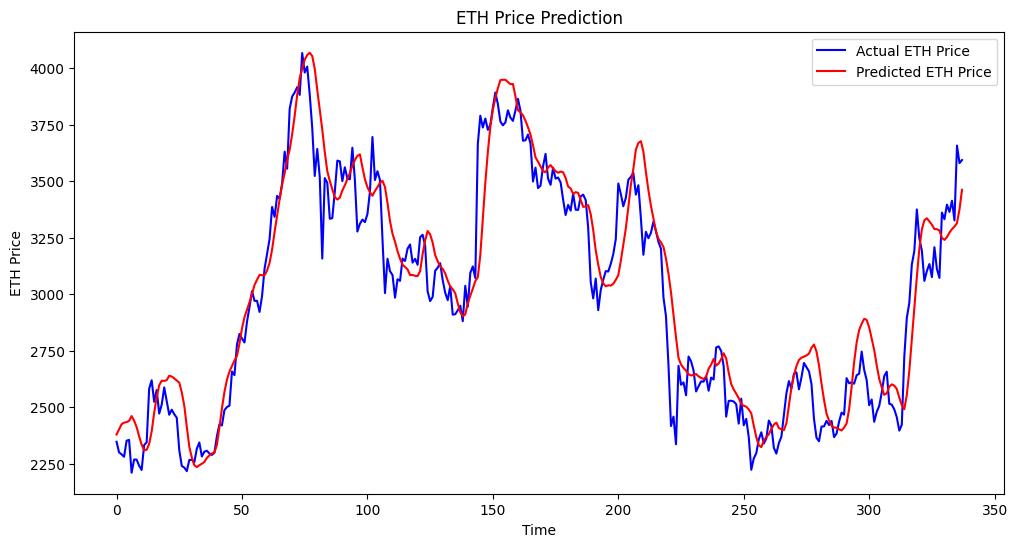

In [ ]:
# BTC predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(btc_actual, label="Actual BTC Price", color='blue')
plt.plot(btc_predictions, label="Predicted BTC Price", color='red')
plt.title("BTC Price Prediction")
plt.xlabel("Time")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

# ETH predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(eth_actual, label="Actual ETH Price", color='blue')
plt.plot(eth_predictions, label="Predicted ETH Price", color='red')
plt.title("ETH Price Prediction")
plt.xlabel("Time")
plt.ylabel("ETH Price")
plt.legend()
plt.show()

In [ ]:
# Import necessary library
from sklearn.metrics import mean_absolute_percentage_error

# Ensure the actual values and predictions are reshaped correctly
btc_actual = btc_actual.reshape(-1, 1)
btc_predictions = btc_predictions.reshape(-1, 1)

eth_actual = eth_actual.reshape(-1, 1)
eth_predictions = eth_predictions.reshape(-1, 1)

# Calculate MAPE for BTC and ETH models
btc_mape = mean_absolute_percentage_error(btc_actual, btc_predictions)
eth_mape = mean_absolute_percentage_error(eth_actual, eth_predictions)

# Convert MAPE to accuracy percentage
btc_accuracy = 100 - (btc_mape * 100)
eth_accuracy = 100 - (eth_mape * 100)

# Display the results
print(f"BTC LSTM Model Accuracy: {btc_accuracy:.2f}%")
print(f"ETH LSTM Model Accuracy: {eth_accuracy:.2f}%")

BTC LSTM Model Accuracy: 96.34%
ETH LSTM Model Accuracy: 95.74%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure actual values and predictions are properly shaped
btc_actual = btc_actual.reshape(-1, 1)
btc_predictions = btc_predictions.reshape(-1, 1)

eth_actual = eth_actual.reshape(-1, 1)
eth_predictions = eth_predictions.reshape(-1, 1)

# Calculate Mean Absolute Error (MAE)
btc_mae = mean_absolute_error(btc_actual, btc_predictions)
eth_mae = mean_absolute_error(eth_actual, eth_predictions)

# Calculate Mean Squared Error (MSE)
btc_mse = mean_squared_error(btc_actual, btc_predictions)
eth_mse = mean_squared_error(eth_actual, eth_predictions)

# Calculate Root Mean Squared Error (RMSE)
btc_rmse = np.sqrt(btc_mse)
eth_rmse = np.sqrt(eth_mse)

# Print all metrics
print(f"BTC Model MAE: {btc_mae:.4f}")
print(f"ETH Model MAE: {eth_mae:.4f}")
print(f"BTC Model MSE: {btc_mse:.4f}")
print(f"ETH Model MSE: {eth_mse:.4f}")
print(f"BTC Model RMSE: {btc_rmse:.4f}")
print(f"ETH Model RMSE: {eth_rmse:.4f}")

BTC Model MAE: 110.8268
ETH Model MAE: 124.2952
BTC Model MSE: 22347.9984
ETH Model MSE: 28133.6569
BTC Model RMSE: 149.4925
ETH Model RMSE: 167.7309


GRU MODEL PREP

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error
import numpy as np

# Initialize GRU model for BTC
gru_btc_model = Sequential()
gru_btc_model.add(GRU(units=64, return_sequences=False, input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])))
gru_btc_model.add(Dense(1))

gru_btc_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the GRU model for BTC
gru_btc_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict on BTC test data
btc_pred_gru = gru_btc_model.predict(X_btc_test)

# Calculate MAE for BTC GRU
btc_mae_gru = mean_absolute_error(y_btc_test, btc_pred_gru)

# Calculate accuracy percentage for BTC GRU
btc_mean_actual = np.mean(y_btc_test)
btc_accuracy_gru = (1 - (btc_mae_gru / btc_mean_actual)) * 100

print(f"GRU BTC MAE: {btc_mae_gru:.4f}")
print(f"GRU BTC Accuracy Percentage: {btc_accuracy_gru:.2f}%")

# ----------------------------------------
# Initialize GRU model for ETH
gru_eth_model = Sequential()
gru_eth_model.add(GRU(units=64, return_sequences=False, input_shape=(X_eth_train.shape[1], X_eth_train.shape[2])))
gru_eth_model.add(Dense(1))

gru_eth_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the GRU model for ETH
gru_eth_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict on ETH test data
eth_pred_gru = gru_eth_model.predict(X_eth_test)

# Calculate MAE for ETH GRU
eth_mae_gru = mean_absolute_error(y_eth_test, eth_pred_gru)

# Calculate accuracy percentage for ETH GRU
eth_mean_actual = np.mean(y_eth_test)
eth_accuracy_gru = (1 - (eth_mae_gru / eth_mean_actual)) * 100

print(f"GRU ETH MAE: {eth_mae_gru:.4f}")
print(f"GRU ETH Accuracy Percentage: {eth_accuracy_gru:.2f}%")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0684
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0026
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 6.5966e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 3.9414e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 3.2854e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 2.7478e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.4812e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.6638e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2.3535e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
GRU BTC MAE: 0.0170
GRU BTC Accuracy Percentage: 97.23%
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0556
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0022
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.9488e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 7.9403e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 6.7182e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 6.9942e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 6.5736e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 5.5889e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 6.8827e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 5.4052e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
GRU ETH MAE: 0.0215
GRU ETH Accuracy Percentage: 96.47%


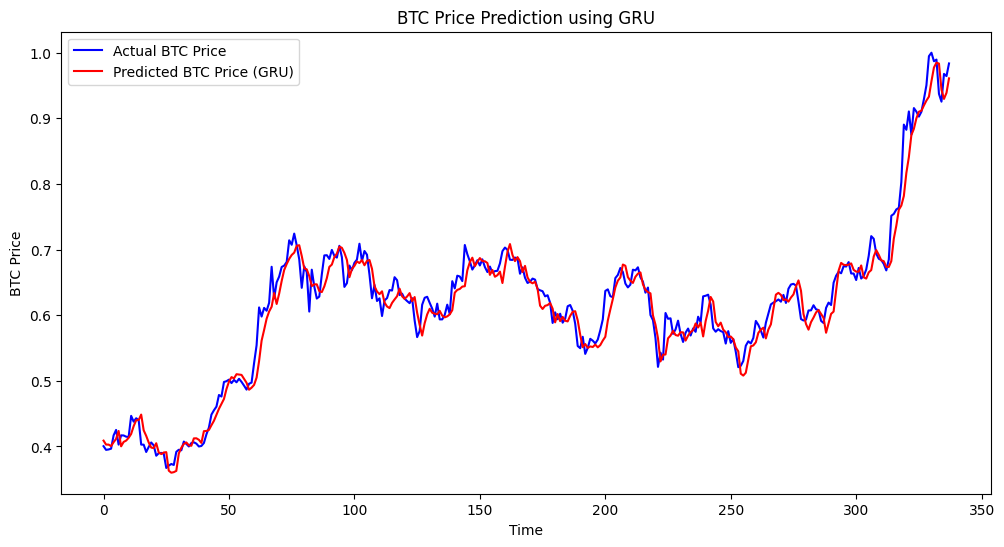

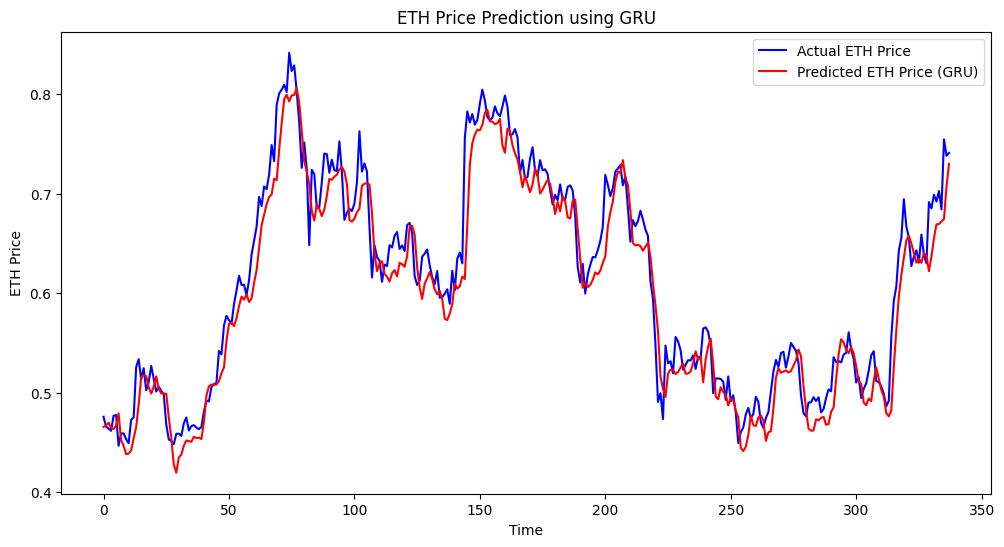

In [ ]:
import matplotlib.pyplot as plt

# Plot BTC predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_btc_test, label="Actual BTC Price", color='blue')
plt.plot(btc_pred_gru, label="Predicted BTC Price (GRU)", color='red')
plt.title("BTC Price Prediction using GRU")
plt.xlabel("Time")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

# Plot ETH predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_eth_test, label="Actual ETH Price", color='blue')
plt.plot(eth_pred_gru, label="Predicted ETH Price (GRU)", color='red')
plt.title("ETH Price Prediction using GRU")
plt.xlabel("Time")
plt.ylabel("ETH Price")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Initialize RNN model for BTC
rnn_btc_model = Sequential()
rnn_btc_model.add(SimpleRNN(units=64, return_sequences=False, input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])))
rnn_btc_model.add(Dense(1))

rnn_btc_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train BTC RNN model
rnn_btc_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict BTC prices
btc_pred_rnn = rnn_btc_model.predict(X_btc_test)

# Calculate MAE for BTC
btc_mae_rnn = mean_absolute_error(y_btc_test, btc_pred_rnn)
btc_accuracy_rnn = (1 - (btc_mae_rnn / np.mean(y_btc_test))) * 100

print(f"RNN BTC MAE: {btc_mae_rnn:.4f}")
print(f"RNN BTC Accuracy Percentage: {btc_accuracy_rnn:.2f}%")

# Initialize RNN model for ETH
rnn_eth_model = Sequential()
rnn_eth_model.add(SimpleRNN(units=64, return_sequences=False, input_shape=(X_eth_train.shape[1], X_eth_train.shape[2])))
rnn_eth_model.add(Dense(1))

rnn_eth_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train ETH RNN model
rnn_eth_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict ETH prices
eth_pred_rnn = rnn_eth_model.predict(X_eth_test)

# Calculate MAE for ETH
eth_mae_rnn = mean_absolute_error(y_eth_test, eth_pred_rnn)
eth_accuracy_rnn = (1 - (eth_mae_rnn / np.mean(y_eth_test))) * 100

print(f"RNN ETH MAE: {eth_mae_rnn:.4f}")
print(f"RNN ETH Accuracy Percentage: {eth_accuracy_rnn:.2f}%")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1692
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.2870e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.3363e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9282e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.4038e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7397e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7641e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8940e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
RNN BTC MAE: 0.0410
RNN BTC Accuracy Percentage: 93.31%
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0961
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.7593e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.2603e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0011
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
RNN ETH MAE: 0.0235
RNN ETH Accuracy Percentage: 96.16%


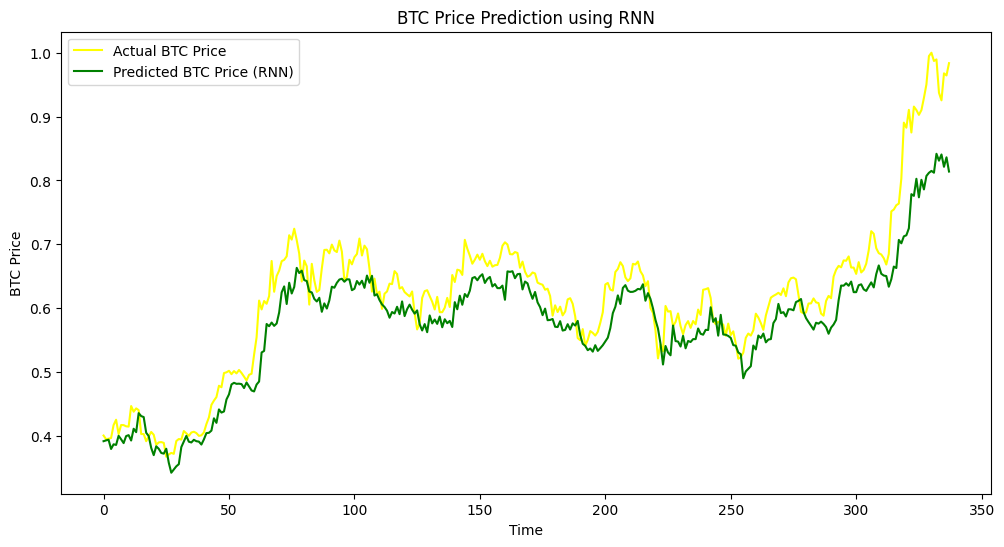

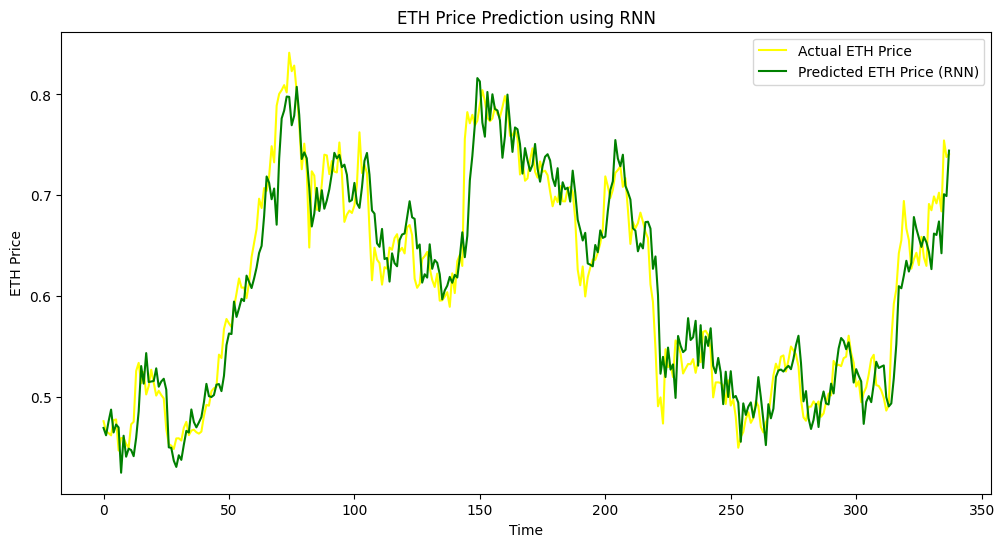

In [ ]:
# Plot BTC predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_btc_test, label="Actual BTC Price", color='yellow')
plt.plot(btc_pred_rnn, label="Predicted BTC Price (RNN)", color='green')
plt.title("BTC Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("BTC Price")
plt.legend()
plt.show()

# Plot ETH predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_eth_test, label="Actual ETH Price", color='yellow')
plt.plot(eth_pred_rnn, label="Predicted ETH Price (RNN)", color='green')
plt.title("ETH Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("ETH Price")
plt.legend()
plt.show()

Bi-LSTM MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# BTC BiLSTM Model
bilstm_btc_model = Sequential()
bilstm_btc_model.add(Bidirectional(LSTM(units=64, return_sequences=False), input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])))
bilstm_btc_model.add(Dense(1))

bilstm_btc_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train BTC BiLSTM model
bilstm_btc_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict BTC prices
btc_pred_bilstm = bilstm_btc_model.predict(X_btc_test)

# Evaluate BTC model
btc_mae_bilstm = mean_absolute_error(y_btc_test, btc_pred_bilstm)
btc_rmse_bilstm = np.sqrt(mean_squared_error(y_btc_test, btc_pred_bilstm))
btc_accuracy_bilstm = 100 - (btc_rmse_bilstm / np.mean(y_btc_test) * 100)

print(f"BTC BiLSTM MAE: {btc_mae_bilstm:.4f}")
print(f"BTC BiLSTM RMSE: {btc_rmse_bilstm:.4f}")
print(f"BTC BiLSTM Accuracy Percentage: {btc_accuracy_bilstm:.2f}%")

# ETH BiLSTM Model
bilstm_eth_model = Sequential()
bilstm_eth_model.add(Bidirectional(LSTM(units=64, return_sequences=False), input_shape=(X_eth_train.shape[1], X_eth_train.shape[2])))
bilstm_eth_model.add(Dense(1))

bilstm_eth_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train ETH BiLSTM model
bilstm_eth_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict ETH prices
eth_pred_bilstm = bilstm_eth_model.predict(X_eth_test)

# Evaluate ETH model
eth_mae_bilstm = mean_absolute_error(y_eth_test, eth_pred_bilstm)
eth_rmse_bilstm = np.sqrt(mean_squared_error(y_eth_test, eth_pred_bilstm))
eth_accuracy_bilstm = 100 - (eth_rmse_bilstm / np.mean(y_eth_test) * 100)

print(f"ETH BiLSTM MAE: {eth_mae_bilstm:.4f}")
print(f"ETH BiLSTM RMSE: {eth_rmse_bilstm:.4f}")
print(f"ETH BiLSTM Accuracy Percentage: {eth_accuracy_bilstm:.2f}%")

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0214
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0014
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 6.8822e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 5.7586e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.5971e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 4.7775e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 4.2366e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 4.1204e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.7463e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.5994e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
BTC BiLSTM MAE: 0.0285
BTC BiLSTM RMSE: 0.0370
BTC BiLSTM Accuracy Percentage: 93.97%
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0190
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0016
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0012
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0015
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0011
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 9.0899e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.8059e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 8.2415e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.8188e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 8.1613e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
ETH BiLSTM MAE: 0.0301
ETH BiLSTM RMSE: 0.0374
ETH BiLSTM Accuracy Percentage: 93.88%


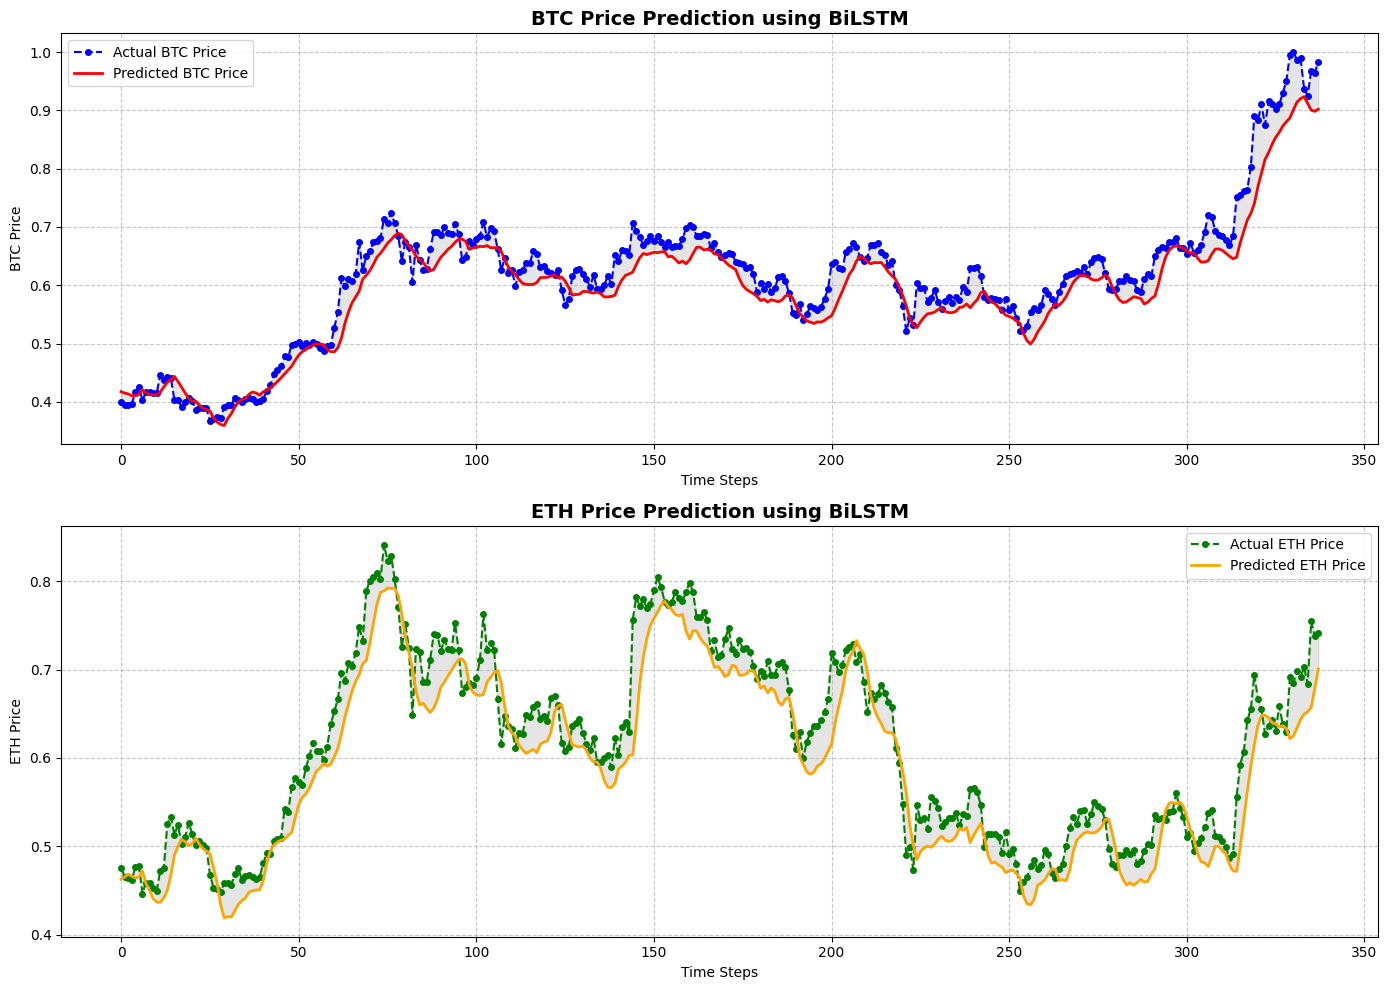

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# BTC Plot
ax[0].plot(y_btc_test, label="Actual BTC Price", color='blue', linestyle='dashed', marker='o', markersize=4)
ax[0].plot(btc_pred_bilstm, label="Predicted BTC Price", color='red', linewidth=2)
ax[0].fill_between(range(len(y_btc_test)), y_btc_test.flatten(), btc_pred_bilstm.flatten(), color='gray', alpha=0.2)
ax[0].set_title("BTC Price Prediction using BiLSTM", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Time Steps")
ax[0].set_ylabel("BTC Price")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

# ETH Plot
ax[1].plot(y_eth_test, label="Actual ETH Price", color='green', linestyle='dashed', marker='o', markersize=4)
ax[1].plot(eth_pred_bilstm, label="Predicted ETH Price", color='orange', linewidth=2)
ax[1].fill_between(range(len(y_eth_test)), y_eth_test.flatten(), eth_pred_bilstm.flatten(), color='gray', alpha=0.2)
ax[1].set_title("ETH Price Prediction using BiLSTM", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("ETH Price")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show
plt.tight_layout()
plt.show()

1D CNN

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0154
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.8451e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.8884e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.4250e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2994e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7061e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.2134e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0121
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━

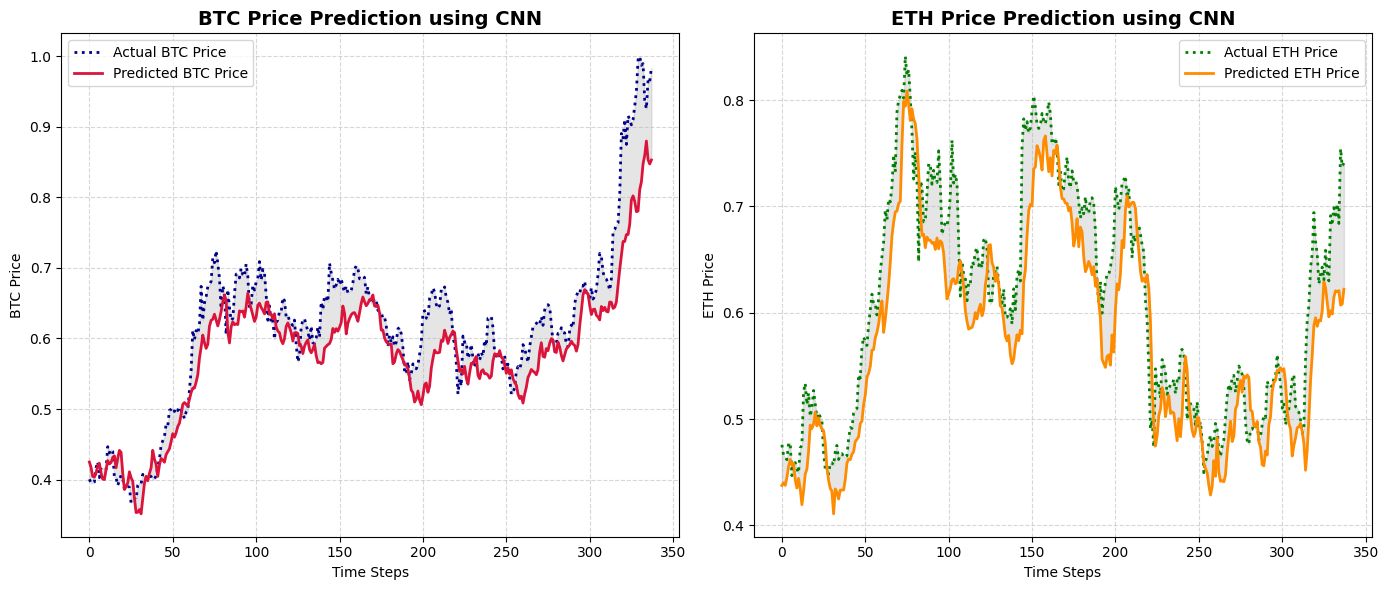

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize CNN model for BTC
cnn_btc_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(1)
])

cnn_btc_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train CNN BTC model
cnn_btc_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict on BTC test data
btc_pred_cnn = cnn_btc_model.predict(X_btc_test)

# Initialize CNN model for ETH
cnn_eth_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_eth_train.shape[1], X_eth_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(1)
])

cnn_eth_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train CNN ETH model
cnn_eth_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict on ETH test data
eth_pred_cnn = cnn_eth_model.predict(X_eth_test)

# Evaluate models
btc_mae_cnn = mean_absolute_error(y_btc_test, btc_pred_cnn)
eth_mae_cnn = mean_absolute_error(y_eth_test, eth_pred_cnn)

btc_rmse_cnn = np.sqrt(mean_squared_error(y_btc_test, btc_pred_cnn))
eth_rmse_cnn = np.sqrt(mean_squared_error(y_eth_test, eth_pred_cnn))

btc_cnn_accuracy = 100 - (btc_rmse_cnn / np.mean(y_btc_test) * 100)
eth_cnn_accuracy = 100 - (eth_rmse_cnn / np.mean(y_eth_test) * 100)

print(f"CNN BTC MAE: {btc_mae_cnn}")
print(f"CNN ETH MAE: {eth_mae_cnn}")
print(f"CNN BTC RMSE: {btc_rmse_cnn}")
print(f"CNN ETH RMSE: {eth_rmse_cnn}")
print(f"CNN BTC Accuracy Percentage: {btc_cnn_accuracy}%")
print(f"CNN ETH Accuracy Percentage: {eth_cnn_accuracy}%")

import matplotlib.pyplot as plt

# Create a figure with a distinctive layout
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# BTC Plot with gradient color and dashed lines
ax[0].plot(y_btc_test, label="Actual BTC Price", color='darkblue', linestyle='dotted', linewidth=2)
ax[0].plot(btc_pred_cnn, label="Predicted BTC Price", color='crimson', linewidth=2)
ax[0].fill_between(range(len(y_btc_test)), y_btc_test.flatten(), btc_pred_cnn.flatten(), color='gray', alpha=0.2)
ax[0].set_title("BTC Price Prediction using CNN", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Time Steps")
ax[0].set_ylabel("BTC Price")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# ETH Plot with markers and different color scheme
ax[1].plot(y_eth_test, label="Actual ETH Price", color='green', linestyle='dotted', linewidth=2)
ax[1].plot(eth_pred_cnn, label="Predicted ETH Price", color='darkorange', linewidth=2)
ax[1].fill_between(range(len(y_eth_test)), y_eth_test.flatten(), eth_pred_cnn.flatten(), color='gray', alpha=0.2)
ax[1].set_title("ETH Price Prediction using CNN", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Time Steps")
ax[1].set_ylabel("ETH Price")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

ATTENTION BASED MODEL

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Attention, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import tensorflow as tf

# Define Attention LSTM Model for BTC
btc_input = Input(shape=(X_btc_train.shape[1], X_btc_train.shape[2]))
btc_attention = Attention()([btc_input, btc_input])
btc_lstm = LSTM(64, return_sequences=False)(btc_attention)
btc_output = Dense(1)(btc_lstm)

btc_attention_lstm_model = tf.keras.Model(inputs=btc_input, outputs=btc_output)
btc_attention_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train BTC Model
btc_attention_lstm_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict on BTC test data
btc_pred_attention_lstm = btc_attention_lstm_model.predict(X_btc_test)

# Define Attention LSTM Model for ETH
eth_input = Input(shape=(X_eth_train.shape[1], X_eth_train.shape[2]))
eth_attention = Attention()([eth_input, eth_input])
eth_lstm = LSTM(64, return_sequences=False)(eth_attention)
eth_output = Dense(1)(eth_lstm)

eth_attention_lstm_model = tf.keras.Model(inputs=eth_input, outputs=eth_output)
eth_attention_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train ETH Model
eth_attention_lstm_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict on ETH test data
eth_pred_attention_lstm = eth_attention_lstm_model.predict(X_eth_test)

# Evaluate the BTC Model
btc_mae_attention_lstm = mean_absolute_error(y_btc_test, btc_pred_attention_lstm)
btc_rmse_attention_lstm = np.sqrt(mean_squared_error(y_btc_test, btc_pred_attention_lstm))
btc_attention_lstm_accuracy = 100 - (btc_rmse_attention_lstm / np.mean(y_btc_test) * 100)

# Evaluate the ETH Model
eth_mae_attention_lstm = mean_absolute_error(y_eth_test, eth_pred_attention_lstm)
eth_rmse_attention_lstm = np.sqrt(mean_squared_error(y_eth_test, eth_pred_attention_lstm))
eth_attention_lstm_accuracy = 100 - (eth_rmse_attention_lstm / np.mean(y_eth_test) * 100)

# Print Results
print(f"Attention-based LSTM BTC MAE: {btc_mae_attention_lstm}")
print(f"Attention-based LSTM ETH MAE: {eth_mae_attention_lstm}")
print(f"Attention-based LSTM BTC RMSE: {btc_rmse_attention_lstm}")
print(f"Attention-based LSTM ETH RMSE: {eth_rmse_attention_lstm}")
print(f"Attention-based LSTM BTC Accuracy Percentage: {btc_attention_lstm_accuracy}%")
print(f"Attention-based LSTM ETH Accuracy Percentage: {eth_attention_lstm_accuracy}%")


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0168
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0032
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0022
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0017
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0015
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0015
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0378
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0061
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0058
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0051
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━

1D CNN - LSTM Hybrid

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize CNN-LSTM model for BTC
btc_cnn_lstm_model = Sequential()
btc_cnn_lstm_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])))
btc_cnn_lstm_model.add(MaxPooling1D(pool_size=2))
btc_cnn_lstm_model.add(LSTM(units=64, return_sequences=False))
btc_cnn_lstm_model.add(Dense(1))

btc_cnn_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train BTC CNN-LSTM model
btc_cnn_lstm_model.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)

# Predict on BTC test data
btc_pred_cnn_lstm = btc_cnn_lstm_model.predict(X_btc_test)

# Initialize CNN-LSTM model for ETH
eth_cnn_lstm_model = Sequential()
eth_cnn_lstm_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_eth_train.shape[1], X_eth_train.shape[2])))
eth_cnn_lstm_model.add(MaxPooling1D(pool_size=2))
eth_cnn_lstm_model.add(LSTM(units=64, return_sequences=False))
eth_cnn_lstm_model.add(Dense(1))

eth_cnn_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error')

# Train ETH CNN-LSTM model
eth_cnn_lstm_model.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)

# Predict on ETH test data
eth_pred_cnn_lstm = eth_cnn_lstm_model.predict(X_eth_test)

# Evaluate BTC Model
btc_mae_cnn_lstm = mean_absolute_error(y_btc_test, btc_pred_cnn_lstm)
btc_rmse_cnn_lstm = np.sqrt(mean_squared_error(y_btc_test, btc_pred_cnn_lstm))
btc_cnn_lstm_accuracy = 100 - (btc_rmse_cnn_lstm / np.mean(y_btc_test) * 100)

# Evaluate ETH Model
eth_mae_cnn_lstm = mean_absolute_error(y_eth_test, eth_pred_cnn_lstm)
eth_rmse_cnn_lstm = np.sqrt(mean_squared_error(y_eth_test, eth_pred_cnn_lstm))
eth_cnn_lstm_accuracy = 100 - (eth_rmse_cnn_lstm / np.mean(y_eth_test) * 100)

# Print Results
print(f"CNN-LSTM BTC MAE: {btc_mae_cnn_lstm}")
print(f"CNN-LSTM ETH MAE: {eth_mae_cnn_lstm}")
print(f"CNN-LSTM BTC RMSE: {btc_rmse_cnn_lstm}")
print(f"CNN-LSTM ETH RMSE: {eth_rmse_cnn_lstm}")
print(f"CNN-LSTM BTC Accuracy Percentage: {btc_cnn_lstm_accuracy}%")
print(f"CNN-LSTM ETH Accuracy Percentage: {eth_cnn_lstm_accuracy}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0529
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0016
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.7819e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.0850e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.6068e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.0354e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 5.0600e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.0627e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.4728e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.8958e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0514
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0029
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0017
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015
Epo

Transformer-LSTM Hybrid

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0254
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0034
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0022
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0017
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0016
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0013
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0014
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0014
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0239
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0059
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0052
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0041
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━

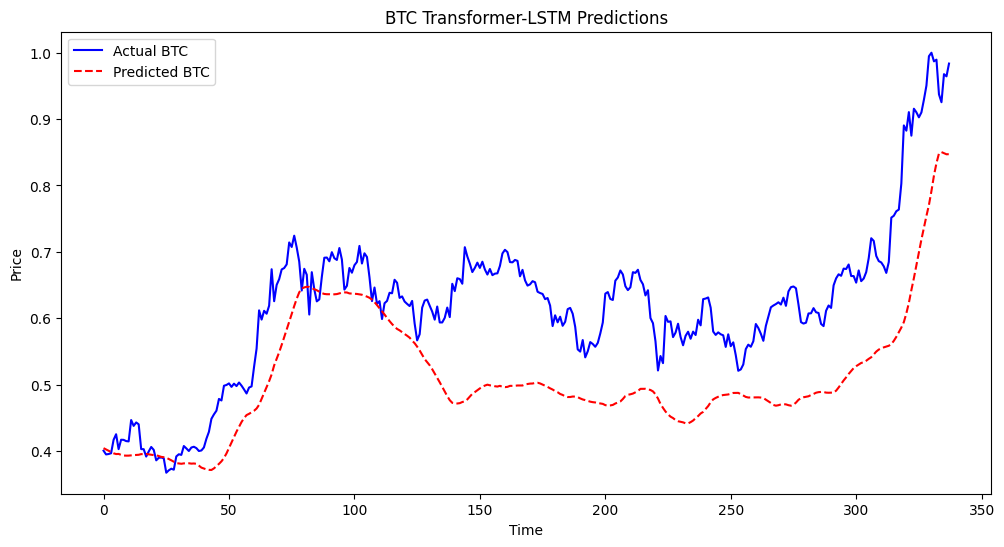

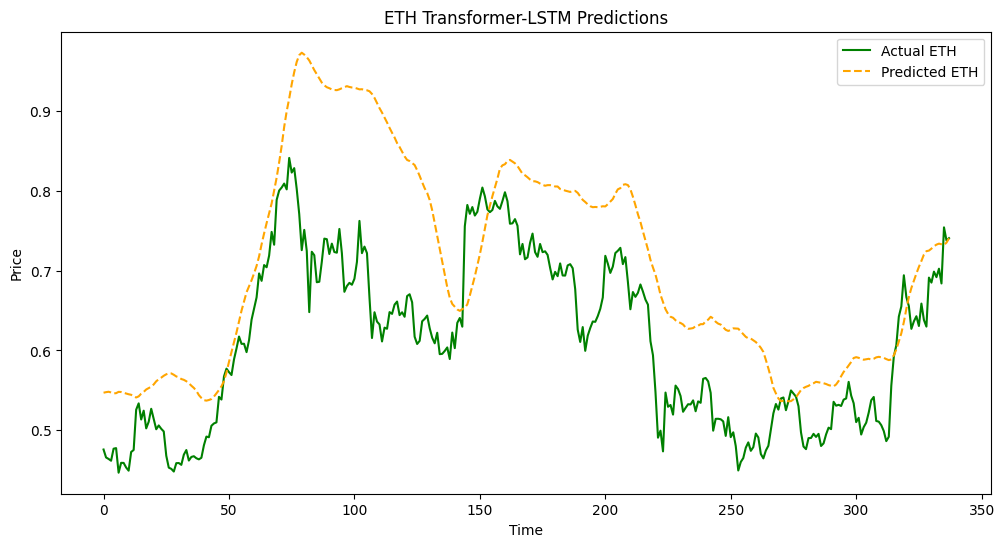

------ BTC Transformer-LSTM Model Performance ------
MAE: 0.1053
RMSE: 0.1224
Accuracy Percentage: 80.04%

------ ETH Transformer-LSTM Model Performance ------
MAE: 0.0994
RMSE: 0.1198
Accuracy Percentage: 80.37%


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Attention, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define model architecture
def create_transformer_lstm():
    input_layer = Input(shape=(X_btc_train.shape[1], X_btc_train.shape[2]))
    attention_layer = Attention()([input_layer, input_layer])
    lstm_layer = LSTM(64, return_sequences=False)(attention_layer)
    output_layer = Dense(1)(lstm_layer)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(), loss='mean_squared_error')
    return model

# Train & Evaluate for BTC
transformer_lstm_btc = create_transformer_lstm()
transformer_lstm_btc.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)
y_pred_btc = transformer_lstm_btc.predict(X_btc_test)

# Train & Evaluate for ETH
transformer_lstm_eth = create_transformer_lstm()
transformer_lstm_eth.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)
y_pred_eth = transformer_lstm_eth.predict(X_eth_test)

# Plot BTC predictions
plt.figure(figsize=(12, 6))
plt.plot(y_btc_test, label="Actual BTC", color="blue")
plt.plot(y_pred_btc, label="Predicted BTC", linestyle="dashed", color="red")
plt.title("BTC Transformer-LSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Plot ETH predictions
plt.figure(figsize=(12, 6))
plt.plot(y_eth_test, label="Actual ETH", color="green")
plt.plot(y_pred_eth, label="Predicted ETH", linestyle="dashed", color="orange")
plt.title("ETH Transformer-LSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Accuracy calculation for BTC
mae_btc = mean_absolute_error(y_btc_test, y_pred_btc)
rmse_btc = np.sqrt(mean_squared_error(y_btc_test, y_pred_btc))
accuracy_btc = 100 - (rmse_btc / np.mean(y_btc_test) * 100)

# Accuracy calculation for ETH
mae_eth = mean_absolute_error(y_eth_test, y_pred_eth)
rmse_eth = np.sqrt(mean_squared_error(y_eth_test, y_pred_eth))
accuracy_eth = 100 - (rmse_eth / np.mean(y_eth_test) * 100)

# Display BTC results
print(f"------ BTC Transformer-LSTM Model Performance ------")
print(f"MAE: {mae_btc:.4f}")
print(f"RMSE: {rmse_btc:.4f}")
print(f"Accuracy Percentage: {accuracy_btc:.2f}%\n")

# Display ETH results
print(f"------ ETH Transformer-LSTM Model Performance ------")
print(f"MAE: {mae_eth:.4f}")
print(f"RMSE: {rmse_eth:.4f}")
print(f"Accuracy Percentage: {accuracy_eth:.2f}%")


CNN-BiLSTM Hybrid

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0514
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0022
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 9.7526e-04
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 7.8786e-04
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.4211e-04
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.0420e-04
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 6.6899e-04
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.1530e-04
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.5839e-04
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 5.5766e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0368
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0023
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0017
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0018
Epo

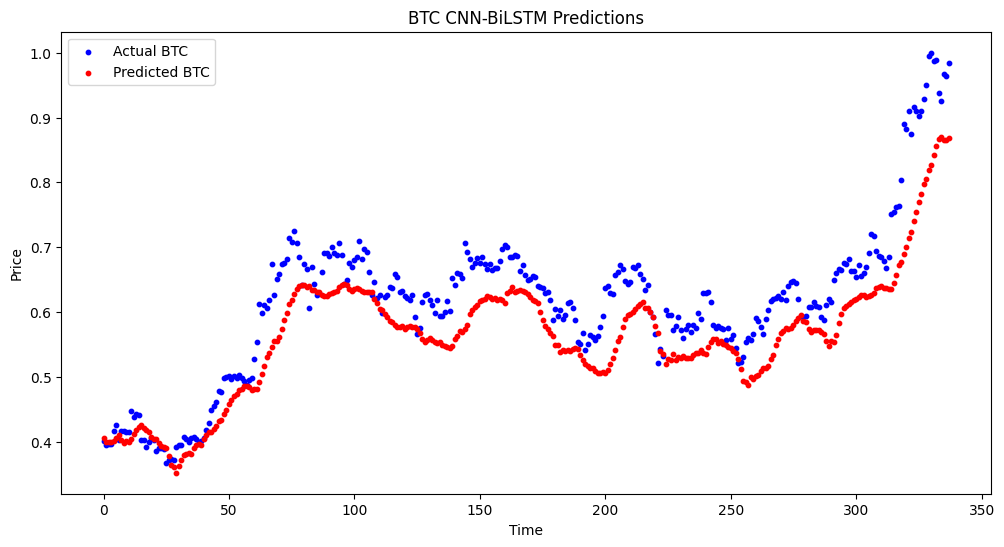

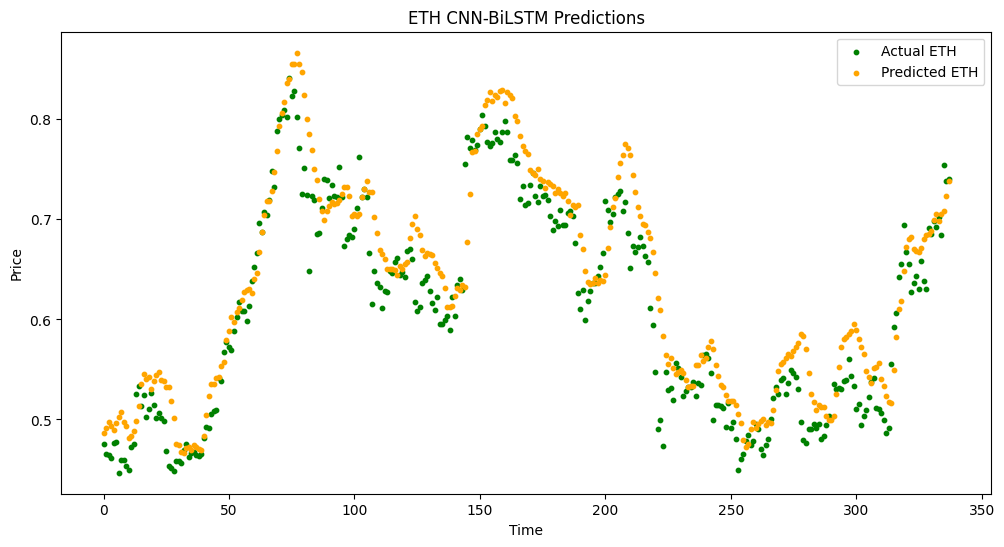

------ BTC CNN-BiLSTM Model Performance ------
MAE: 0.0535
RMSE: 0.0652
Accuracy Percentage: 89.37%

------ ETH CNN-BiLSTM Model Performance ------
MAE: 0.0306
RMSE: 0.0401
Accuracy Percentage: 93.43%


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define CNN + BiLSTM model
def create_cnn_bilstm():
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_btc_train.shape[1], X_btc_train.shape[2])),
        MaxPooling1D(pool_size=2),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(), loss='mean_squared_error')
    return model

# Train & Evaluate for BTC
cnn_bilstm_btc = create_cnn_bilstm()
cnn_bilstm_btc.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)
y_pred_btc = cnn_bilstm_btc.predict(X_btc_test)

# Train & Evaluate for ETH
cnn_bilstm_eth = create_cnn_bilstm()
cnn_bilstm_eth.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)
y_pred_eth = cnn_bilstm_eth.predict(X_eth_test)

# Save the trained models
cnn_bilstm_btc_model.save("cnn_bilstm_btc_model.h5")
cnn_bilstm_eth_model.save("cnn_bilstm_eth_model.h5")

# Plot BTC Predictions with Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_btc_test)), y_btc_test, label="Actual BTC", color="blue", s=10)
plt.scatter(range(len(y_pred_btc)), y_pred_btc, label="Predicted BTC", color="red", s=10)
plt.title("BTC CNN-BiLSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Plot ETH Predictions with Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_eth_test)), y_eth_test, label="Actual ETH", color="green", s=10)
plt.scatter(range(len(y_pred_eth)), y_pred_eth, label="Predicted ETH", color="orange", s=10)
plt.title("ETH CNN-BiLSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Accuracy calculation for BTC
mae_btc = mean_absolute_error(y_btc_test, y_pred_btc)
rmse_btc = np.sqrt(mean_squared_error(y_btc_test, y_pred_btc))
accuracy_btc = 100 - (rmse_btc / np.mean(y_btc_test) * 100)

# Accuracy calculation for ETH
mae_eth = mean_absolute_error(y_eth_test, y_pred_eth)
rmse_eth = np.sqrt(mean_squared_error(y_eth_test, y_pred_eth))
accuracy_eth = 100 - (rmse_eth / np.mean(y_eth_test) * 100)

# Display BTC results
print(f"------ BTC CNN-BiLSTM Model Performance ------")
print(f"MAE: {mae_btc:.4f}")
print(f"RMSE: {rmse_btc:.4f}")
print(f"Accuracy Percentage: {accuracy_btc:.2f}%\n")

# Display ETH results
print(f"------ ETH CNN-BiLSTM Model Performance ------")
print(f"MAE: {mae_eth:.4f}")
print(f"RMSE: {rmse_eth:.4f}")
print(f"Accuracy Percentage: {accuracy_eth:.2f}%")


GRU + Attention Based LSTM

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0166
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0031
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0021
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0019
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0016
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0020
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0016
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0016
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0014
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0015
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0532
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0061
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0057
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0051
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━

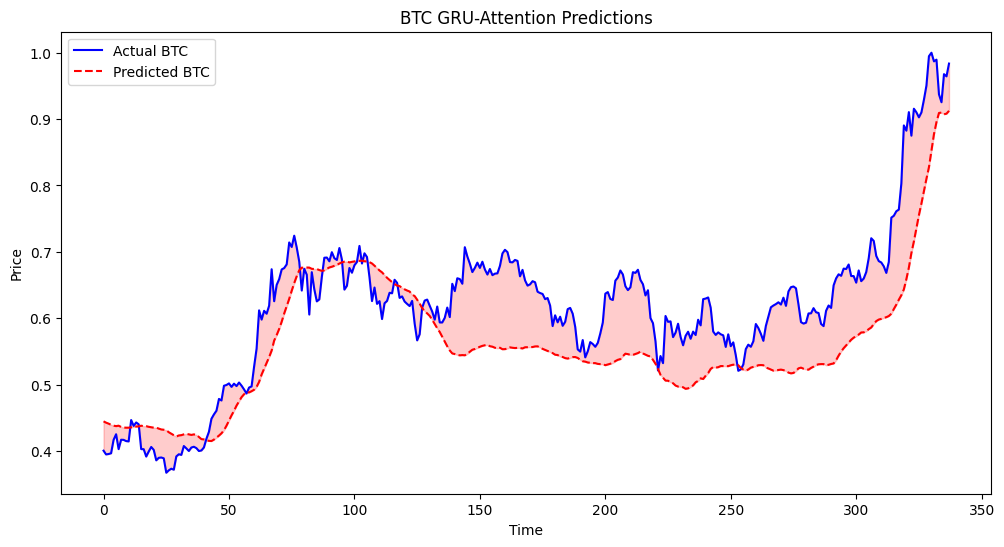

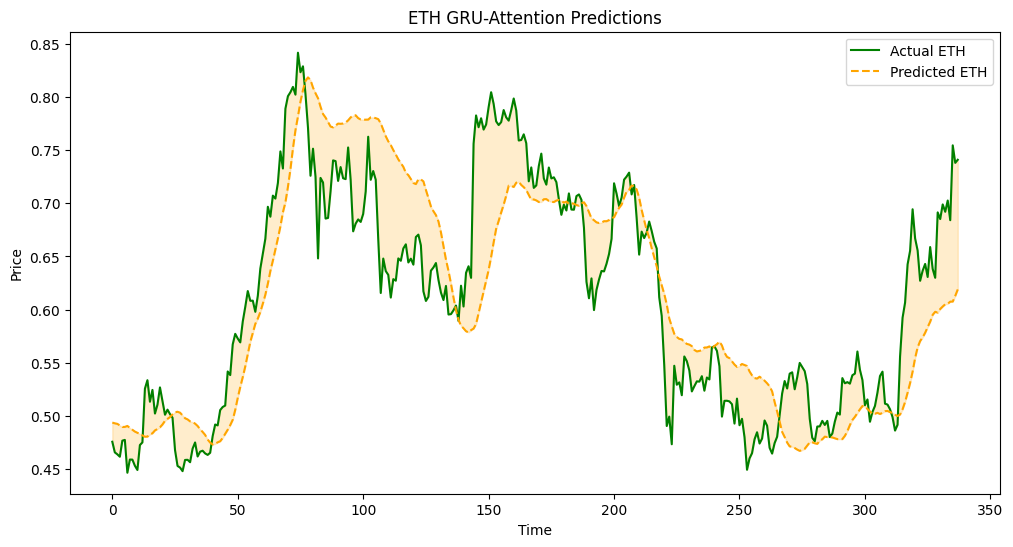

------ BTC GRU-Attention Model Performance ------
MAE: 0.0672
RMSE: 0.0813
Accuracy Percentage: 86.75%

------ ETH GRU-Attention Model Performance ------
MAE: 0.0495
RMSE: 0.0621
Accuracy Percentage: 89.82%


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GRU, Attention, Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define GRU + Attention model
def create_gru_attention():
    input_layer = Input(shape=(X_btc_train.shape[1], X_btc_train.shape[2]))
    attention_layer = Attention()([input_layer, input_layer])
    gru_layer = GRU(64, return_sequences=False)(attention_layer)
    output_layer = Dense(1)(gru_layer)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(), loss='mean_squared_error')
    return model

# Train & Evaluate for BTC
gru_attention_btc = create_gru_attention()
gru_attention_btc.fit(X_btc_train, y_btc_train, epochs=10, batch_size=32)
y_pred_btc = gru_attention_btc.predict(X_btc_test)

# Train & Evaluate for ETH
gru_attention_eth = create_gru_attention()
gru_attention_eth.fit(X_eth_train, y_eth_train, epochs=10, batch_size=32)
y_pred_eth = gru_attention_eth.predict(X_eth_test)

# Plot BTC Predictions with Shaded Error
plt.figure(figsize=(12, 6))
plt.plot(y_btc_test, label="Actual BTC", color="blue")
plt.plot(y_pred_btc, label="Predicted BTC", linestyle="dashed", color="red")
plt.fill_between(range(len(y_btc_test)), y_btc_test.flatten(), y_pred_btc.flatten(), color='red', alpha=0.2)
plt.title("BTC GRU-Attention Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Plot ETH Predictions with Shaded Error
plt.figure(figsize=(12, 6))
plt.plot(y_eth_test, label="Actual ETH", color="green")
plt.plot(y_pred_eth, label="Predicted ETH", linestyle="dashed", color="orange")
plt.fill_between(range(len(y_eth_test)), y_eth_test.flatten(), y_pred_eth.flatten(), color='orange', alpha=0.2)
plt.title("ETH GRU-Attention Predictions")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Accuracy calculation for BTC
mae_btc = mean_absolute_error(y_btc_test, y_pred_btc)
rmse_btc = np.sqrt(mean_squared_error(y_btc_test, y_pred_btc))
accuracy_btc = 100 - (rmse_btc / np.mean(y_btc_test) * 100)

# Accuracy calculation for ETH
mae_eth = mean_absolute_error(y_eth_test, y_pred_eth)
rmse_eth = np.sqrt(mean_squared_error(y_eth_test, y_pred_eth))
accuracy_eth = 100 - (rmse_eth / np.mean(y_eth_test) * 100)

# Display BTC results
print(f"------ BTC GRU-Attention Model Performance ------")
print(f"MAE: {mae_btc:.4f}")
print(f"RMSE: {rmse_btc:.4f}")
print(f"Accuracy Percentage: {accuracy_btc:.2f}%\n")

# Display ETH results
print(f"------ ETH GRU-Attention Model Performance ------")
print(f"MAE: {mae_eth:.4f}")
print(f"RMSE: {rmse_eth:.4f}")
print(f"Accuracy Percentage: {accuracy_eth:.2f}%")

In [ ]:
import pandas as pd

# Create a dictionary with model names and accuracy values
accuracy_data = {
    'Model': [
        'RNN', 'GRU', 'LSTM', 'BiLSTM', 'CNN',
        'Attention-based LSTM', 'CNN-LSTM', 'CNN-BiLSTM', 'GRU-Attention', 'Transformer-LSTM'
    ],
    'BTC Accuracy (%)': [
        93.31, 97.23, 96.34, 93.97, 90.76,
        81.74, 93.87, 93.42, 86.75, 80.04
    ],
    'ETH Accuracy (%)': [
        96.16, 96.47, 95.74, 93.88, 91.52,
        86.97, 93.77, 94.56, 89.82, 80.37
    ]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(accuracy_data)

# Display the table
print(accuracy_df)

                  Model  BTC Accuracy (%)  ETH Accuracy (%)
0                   RNN             93.31             96.16
1                   GRU             97.23             96.47
2                  LSTM             96.34             95.74
3                BiLSTM             93.97             93.88
4                   CNN             90.76             91.52
5  Attention-based LSTM             81.74             86.97
6              CNN-LSTM             93.87             93.77
7            CNN-BiLSTM             93.42             94.56
8         GRU-Attention             86.75             89.82
9      Transformer-LSTM             80.04             80.37


In [ ]:
!pip install yfinance plotly --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# Download BTC and ETH data
btc_data = yf.download("BTC-USD", start="2020-01-01")
eth_data = yf.download("ETH-USD", start="2020-01-01")

# Keep only Open and Close
btc_data = btc_data[['Open', 'Close']]
eth_data = eth_data[['Open', 'Close']]

# Add technical indicators
def add_indicators(df):
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_20'] = df['Close'].rolling(window=20).mean()
    df['RSI'] = 100 - (100 / (1 + df['Close'].pct_change().add(1).rolling(window=14).apply(
        lambda x: (x[x > 1].mean() / x[x <= 1].mean()) if x[x <= 1].mean() != 0 else 0)))
    return df.dropna()

btc_data = add_indicators(btc_data)
eth_data = add_indicators(eth_data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-21-2f247a8f6a89>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_5'] = df['Close'].rolling(window=5).mean()
<ipython-input-21-2f247a8f6a89>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_20'] = df['Close'].rolling(window=20).mean()


In [ ]:
scaler_btc = MinMaxScaler()
scaler_eth = MinMaxScaler()

btc_scaled = scaler_btc.fit_transform(btc_data)
eth_scaled = scaler_eth.fit_transform(eth_data)

def create_sequences(data, n_steps=30):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_btc, y_btc = create_sequences(btc_scaled)
X_eth, y_eth = create_sequences(eth_scaled)

In [ ]:
def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dense(5))
    model.compile(optimizer='adam', loss='mse')
    return model

model_btc = build_model((X_btc.shape[1], X_btc.shape[2]))
model_eth = build_model((X_eth.shape[1], X_eth.shape[2]))

model_btc.fit(X_btc, y_btc, epochs=10, batch_size=32, verbose=0)
model_eth.fit(X_eth, y_eth, epochs=10, batch_size=32, verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
def predict_and_plot(symbol="BTC"):
    if symbol == "BTC":
        df, model, scaler = btc_data, model_btc, scaler_btc
    else:
        df, model, scaler = eth_data, model_eth, scaler_eth

    last_30_days = df[-30:]
    scaled = scaler.transform(last_30_days)
    input_seq = np.expand_dims(scaled, axis=0)
    prediction = model.predict(input_seq)[0]

    open_price = scaler.inverse_transform([[prediction[0]] + [0] * (scaled.shape[1]-1)])[0][0]
    close_price = scaler.inverse_transform([[0, prediction[1]] + [0] * (scaled.shape[1]-2)])[0][1]

    fig = go.Figure()
    fig.add_trace(go.Candlestick(
        x=df.index[-60:],
        open=df['Open'][-60:],
        high=df['Open'][-60:] + 100,
        low=df['Close'][-60:] - 100,
        close=df['Close'][-60:],
        name=f"{symbol} Candlestick"
    ))

    fig.add_trace(go.Scatter(x=df.index[-60:], y=df['MA_5'][-60:], mode='lines', name='MA 5', line=dict(color='orange')))
    fig.add_trace(go.Scatter(x=df.index[-60:], y=df['MA_20'][-60:], mode='lines', name='MA 20', line=dict(color='blue')))

    fig.add_trace(go.Scatter(
        x=[df.index[-1] + pd.Timedelta(days=1)],
        y=[close_price],
        mode='markers+text', name="Predicted Close",
        text=[f"Close: {close_price:.2f}"],
        marker=dict(color='red', size=12)
    ))

    fig.add_trace(go.Scatter(
        x=[df.index[-1] + pd.Timedelta(days=1)],
        y=[open_price],
        mode='markers+text', name="Predicted Open",
        text=[f"Open: {open_price:.2f}"],
        marker=dict(color='green', size=12)
    ))

    fig.update_layout(title=f"{symbol} Forecast with Indicators", xaxis_title='Date', yaxis_title='Price')
    fig.show()

    print(f"{symbol} Predicted Open: {open_price:.2f} | Close: {close_price:.2f}")

predict_and_plot("ETH")  # or "ETH"

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step


ETH Predicted Open: 1583.20 | Close: 1615.14
